# Operation Chaos Commute — Citi Bike + NOAA Weather

## Members: Shirley (Shuzhou) Li, Wenjun Yao, Sikandar Ali

This notebook continues prior work and findings in the initial_exploration notebook. In this notebook, a few expectations are set:

- monthly JC Citi Bike files in `data/`
- main analysis window: **202102–202602**
- supplemental source: **NOAA CDO v2 API**

The **goal** of this notbook is to continue the existing Citi Bike exploration, then add weather, then demonstrate the “evil” analysis moves from the project plan

## Table of Contents
1. Imports
2. Configuration
3. Helper functions
4. Locate/load/clean Citi Bike
5. NOAA Weather Data Treatments
6. Evil analysis

## 1. Imports

In [1]:
import os
import json
import math
from pathlib import Path
import urllib.parse
import urllib.request
import urllib.error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

## 2. Configuration

Project paths and ranges

In [2]:
# Local files
DATA_DIR = "data"
FALLBACK_DATA_DIR = "."

START_YYYYMM = 202102
END_YYYYMM = 202602

# DEBUG SETTING: set to 3 or 5 if you want only the first couple of files while debugging
SAMPLE_MONTH_LIMIT = None

USE_COLS = [
    "ride_id",
    "rideable_type",
    "started_at",
    "ended_at",
    "start_station_name",
    "start_station_id",
    "end_station_name",
    "end_station_id",
    "start_lat",
    "start_lng",
    "end_lat",
    "end_lng",
    "member_casual",
]

# NOAA weather API
NOAA_TOKEN = "IcIWGudEXyJVisewRmfuijGlbEFIvylZ"
NOAA_BASE = "https://www.ncei.noaa.gov/cdo-web/api/v2"
NOAA_DATASET_ID = "GHCND"
NOAA_DATATYPES = ["TMAX", "TMIN", "PRCP", "SNOW", "AWND"]

WEATHER_START_DATE = "2021-02-01"
WEATHER_END_DATE = "2026-02-28"

# leave blank to auto-pick the first returned station
NOAA_STATION_ID = ""

## 3. Helper Functions

**Project Paths and Trip Files**

In [3]:
def month_sequence(start_yyyymm, end_yyyymm):
    """Return month strings like YYYYMM from start to end, inclusive."""
    months = []
    year = start_yyyymm // 100
    month = start_yyyymm % 100
    end_year = end_yyyymm // 100
    end_month = end_yyyymm % 100

    while (year, month) <= (end_year, end_month):
        months.append(f"{year}{month:02d}")
        month += 1
        if month > 12:
            month = 1
            year += 1

    return months


def candidate_data_dirs(primary="data", fallback="."):
    """Return the folders we want to search for trip files."""
    dirs = [Path(primary), Path(fallback)]
    if dirs[0] == dirs[1]:
        return [dirs[0]]
    return dirs


def find_trip_files(
    primary_dir="data", fallback_dir=".", start_yyyymm=202102, end_yyyymm=202602
):
    """Find Citi Bike files in the requested month range and list missing months."""
    month_ids = month_sequence(start_yyyymm, end_yyyymm)
    matched = []
    search_dirs = candidate_data_dirs(primary_dir, fallback_dir)

    for data_dir in search_dirs:
        if not data_dir.exists():
            continue

        for month_id in month_ids:
            for name in [
                f"JC-{month_id}-citibike-tripdata.csv",
                f"JC-{month_id}-citbike-tripdata.csv",
            ]:
                path = data_dir / name
                if path.exists():
                    matched.append(path)

    matched = sorted(set(matched), key=lambda p: p.name)
    found_names = {p.name for p in matched}
    missing = []

    for month_id in month_ids:
        expected_names = [
            f"JC-{month_id}-citibike-tripdata.csv",
            f"JC-{month_id}-citbike-tripdata.csv",
        ]
        if not any(name in found_names for name in expected_names):
            missing.append(f"JC-{month_id}-citibike-tripdata.csv")

    return matched, missing

**Data Loading & Basic Feature Engineering**

In [4]:
def load_trip_data(files, usecols=None):
    """Read and combine trip CSV files."""
    frames = [pd.read_csv(file, usecols=usecols) for file in files]
    return pd.concat(frames, ignore_index=True)


def missing_summary(df):
    """Show missing counts and percentages by column."""
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
    })
    return summary.sort_values("missing_percent", ascending=False)


def add_time_features(df):
    """Add datetime and trip timing features."""
    out = df.copy()

    out["started_at"] = pd.to_datetime(out["started_at"], errors="coerce")
    out["ended_at"] = pd.to_datetime(out["ended_at"], errors="coerce")

    start = out["started_at"]
    end = out["ended_at"]

    out["tripduration_min"] = (end - start).dt.total_seconds() / 60
    out["date"] = start.dt.normalize()
    out["year"] = start.dt.year
    out["month"] = start.dt.month
    out["month_name"] = start.dt.month_name()
    out["day_of_week"] = start.dt.day_name()
    out["hour"] = start.dt.hour

    out["is_weekend"] = out["day_of_week"].isin(["Saturday", "Sunday"])
    out["is_rush_hour"] = out["hour"].isin([7, 8, 9, 15, 16, 17, 18, 19])
    out["is_round_trip"] = (
        out["start_station_name"].fillna("") == out["end_station_name"].fillna("")
    )
    return out

**NOAA API Requests**

In [5]:
def noaa_get(endpoint, params=None, token=None):
    """Make one NOAA API request and return the JSON response."""
    if not token or not token.strip():
        raise ValueError("NOAA_TOKEN is empty.")

    url = f"{NOAA_BASE}/{endpoint}"
    if params:
        query = urllib.parse.urlencode(params, doseq=True)
        url = f"{url}?{query}"

    request = urllib.request.Request(url, headers={"token": token})
    with urllib.request.urlopen(request, timeout=60) as response:
        return json.loads(response.read().decode("utf-8"))


def noaa_paginated_get(endpoint, params=None, token=None, limit=1000):
    """Fetch all pages of NOAA results and return them as a DataFrame."""
    params = dict(params or {})
    params["limit"] = limit
    offset = 1
    rows = []

    while True:
        params["offset"] = offset
        payload = noaa_get(endpoint, params=params, token=token)
        rows.extend(payload.get("results", []))
        resultset = payload.get("metadata", {}).get("resultset", {})
        count = resultset.get("count", 0)
        returned = resultset.get("limit", limit)
        if count == 0 or offset + returned > count:
            break
        offset += returned

    return pd.DataFrame(rows)

**Weather Data Assembly**

In [6]:
def yearly_date_windows(start_date, end_date):
    """Split a date range into year-sized windows."""
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    windows = []

    for year in range(start.year, end.year + 1):
        window_start = max(start, pd.Timestamp(f"{year}-01-01"))
        window_end = min(end, pd.Timestamp(f"{year}-12-31"))
        windows.append((str(window_start.date()), str(window_end.date())))

    return windows


def fetch_noaa_weather_yearly(
    token, station_id, start_date, end_date, datasetid="GHCND", datatypes=None
):
    """Download NOAA weather data and return long and daily versions."""
    if datatypes is None:
        datatypes = ["TMAX", "TMIN", "PRCP", "SNOW", "AWND"]

    frames = []
    for start_d, end_d in yearly_date_windows(start_date, end_date):
        weather_part = noaa_paginated_get(
            "data",
            params={
                "datasetid": datasetid,
                "stationid": station_id,
                "startdate": start_d,
                "enddate": end_d,
                "units": "metric",
                "datatypeid": datatypes,
            },
            token=token,
            limit=1000,
        )

        if not weather_part.empty:
            frames.append(weather_part)

    if not frames:
        return pd.DataFrame(), pd.DataFrame()

    weather_long = pd.concat(frames, ignore_index=True)
    weather_long["date"] = pd.to_datetime(weather_long["date"], errors="coerce").dt.date
    weather_long["value"] = pd.to_numeric(weather_long["value"], errors="coerce")
    weather_daily = (
        weather_long.pivot_table(
            index="date",
            columns="datatype",
            values="value",
            aggfunc="mean",
        )
        .reset_index()
    )
    weather_daily["date"] = pd.to_datetime(weather_daily["date"])

    if {"TMAX", "TMIN"}.issubset(weather_daily.columns):
        weather_daily["TAVG_EST"] = (weather_daily["TMAX"] + weather_daily["TMIN"]) / 2

    return weather_long, weather_daily

**Evaluation Metrics**

In [7]:
def accuracy_score_manual(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return (y_true == y_pred).mean()


def precision_score_manual(y_true, y_pred, positive=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = ((y_true == positive) & (y_pred == positive)).sum()
    fp = ((y_true != positive) & (y_pred == positive)).sum()
    return tp / (tp + fp) if (tp + fp) > 0 else np.nan


def recall_score_manual(y_true, y_pred, positive=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = ((y_true == positive) & (y_pred == positive)).sum()
    fn = ((y_true == positive) & (y_pred != positive)).sum()
    return tp / (tp + fn) if (tp + fn) > 0 else np.nan


def f1_score_manual(y_true, y_pred, positive=1):
    p = precision_score_manual(y_true, y_pred, positive=positive)
    r = recall_score_manual(y_true, y_pred, positive=positive)
    if pd.isna(p) or pd.isna(r) or (p + r) == 0:
        return np.nan
    return 2 * p * r / (p + r)

## 4. CITI Bike Cleaning & Analysis

In [8]:
trip_files, missing_files = find_trip_files(
    primary_dir=DATA_DIR,
    fallback_dir=FALLBACK_DATA_DIR,
    start_yyyymm=START_YYYYMM,
    end_yyyymm=END_YYYYMM,
)

if SAMPLE_MONTH_LIMIT is not None:
    trip_files = trip_files[:SAMPLE_MONTH_LIMIT]

print("Trip files found:", len(trip_files))
print("First few files:")
for f in trip_files[:5]:
    print(" ", f)

print("\nMissing files in requested range:", len(missing_files))
if len(missing_files) > 0:
    print("First few missing examples:")
    for f in missing_files[:5]:
        print(" ", f)

Trip files found: 61
First few files:
  data/JC-202102-citibike-tripdata.csv
  data/JC-202103-citibike-tripdata.csv
  data/JC-202104-citibike-tripdata.csv
  data/JC-202105-citibike-tripdata.csv
  data/JC-202106-citibike-tripdata.csv

Missing files in requested range: 0


**Load and inspect Citi Bike**

In [9]:
df = load_trip_data(trip_files, usecols=USE_COLS)

print("Raw shape:", df.shape)
display(df.head())
display(missing_summary(df).head(15))

Raw shape: (4638163, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,121DD7DD23CB1335,docked_bike,2021-02-03 23:11:28,2021-02-03 23:18:28,Hoboken Ave at Monmouth St,JC105,Christ Hospital,JC034,40.735208,-74.046964,40.734786,-74.050444,member
1,FD73FB85F008349D,docked_bike,2021-02-27 16:34:05,2021-02-27 16:56:40,Newport Pkwy,JC008,Marin Light Rail,JC013,40.728744,-74.032108,40.714584,-74.042817,member
2,39F9E6663CB5FDF6,docked_bike,2021-02-26 23:16:04,2021-02-26 23:22:25,Journal Square,JC103,Baldwin at Montgomery,JC020,40.733670,-74.062500,40.723659,-74.064194,member
3,A64745CB0792EC6F,docked_bike,2021-02-24 16:51:50,2021-02-24 17:16:09,Hoboken Ave at Monmouth St,JC105,Hoboken Ave at Monmouth St,JC105,40.735208,-74.046963,40.735208,-74.046964,casual
4,75CC76EB9543764A,docked_bike,2021-02-24 20:44:16,2021-02-24 20:44:46,Hoboken Ave at Monmouth St,JC105,Hoboken Ave at Monmouth St,JC105,40.735208,-74.046963,40.735208,-74.046964,member


,missing_count,missing_percent
end_station_id,18998,0.409602
end_station_name,17128,0.369284
end_lat,10187,0.219634
end_lng,10187,0.219634
start_station_name,203,0.004377
start_station_id,203,0.004377
start_lat,3,0.000065
start_lng,3,0.000065
ride_id,0,0.000000
rideable_type,0,0.000000


**Clean and feature-engineer Citi Bike**

Using the previous initial_exploration logics, this inspects missingness, drops missing rows, adds time features, and computes trip duration.

In [10]:
df = df.dropna().copy()
df = add_time_features(df)
df = df.dropna(
    subset=["started_at", "ended_at", "tripduration_min", "date", "hour"]
).copy()
df = df[df["tripduration_min"] >= 0].copy()

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (2854356, 23)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,tripduration_min,date,year,month,month_name,day_of_week,hour,is_weekend,is_rush_hour,is_round_trip
0,121DD7DD23CB1335,docked_bike,2021-02-03 23:11:28,2021-02-03 23:18:28,Hoboken Ave at Monmouth St,JC105,Christ Hospital,JC034,40.735208,-74.046964,40.734786,-74.050444,member,7.000000,2021-02-03,2021.0,2.0,February,Wednesday,23.0,False,False,False
1,FD73FB85F008349D,docked_bike,2021-02-27 16:34:05,2021-02-27 16:56:40,Newport Pkwy,JC008,Marin Light Rail,JC013,40.728744,-74.032108,40.714584,-74.042817,member,22.583333,2021-02-27,2021.0,2.0,February,Saturday,16.0,True,True,False
2,39F9E6663CB5FDF6,docked_bike,2021-02-26 23:16:04,2021-02-26 23:22:25,Journal Square,JC103,Baldwin at Montgomery,JC020,40.733670,-74.062500,40.723659,-74.064194,member,6.350000,2021-02-26,2021.0,2.0,February,Friday,23.0,False,False,False
3,A64745CB0792EC6F,docked_bike,2021-02-24 16:51:50,2021-02-24 17:16:09,Hoboken Ave at Monmouth St,JC105,Hoboken Ave at Monmouth St,JC105,40.735208,-74.046963,40.735208,-74.046964,casual,24.316667,2021-02-24,2021.0,2.0,February,Wednesday,16.0,False,True,True
4,75CC76EB9543764A,docked_bike,2021-02-24 20:44:16,2021-02-24 20:44:46,Hoboken Ave at Monmouth St,JC105,Hoboken Ave at Monmouth St,JC105,40.735208,-74.046963,40.735208,-74.046964,member,0.500000,2021-02-24,2021.0,2.0,February,Wednesday,20.0,False,False,True


**Existing exploration findings**

- August as the busiest month
- a clear day-of-week pattern
- strong late afternoon / evening peaks

In [11]:
month_counts = df["month"].value_counts().sort_index()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_counts = df["day_of_week"].value_counts().reindex(day_order)

hour_counts = df["hour"].value_counts().sort_index()

display(month_counts)
display(day_counts)
display(hour_counts.sort_values(ascending=False).head(10))

month
1.0     132725
2.0     143152
3.0     196797
4.0     245443
5.0     318135
6.0     270854
7.0     296327
8.0     319795
9.0     294458
10.0    274781
11.0    207412
12.0    154477
Name: count, dtype: int64

day_of_week
Monday       380539
Tuesday      409076
Wednesday    428637
Thursday     426246
Friday       428941
Saturday     409372
Sunday       371545
Name: count, dtype: int64

hour
18.0    278205
17.0    273824
19.0    211011
16.0    204902
15.0    176449
8.0     174474
14.0    158233
13.0    155076
12.0    150593
20.0    147611
Name: count, dtype: int64

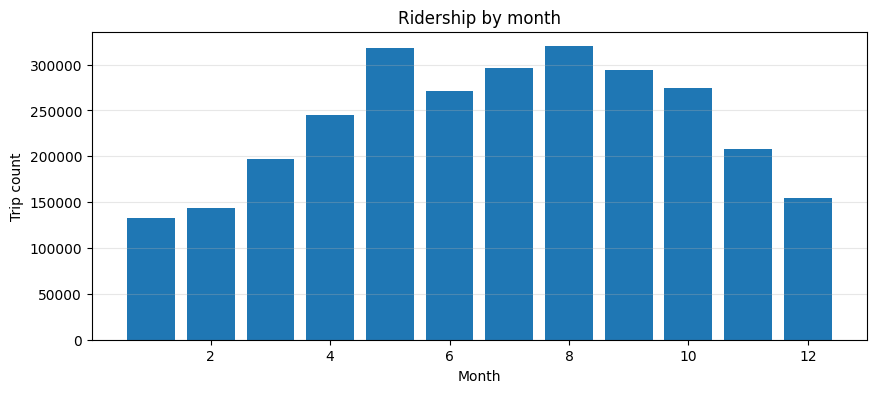

In [12]:
plt.figure(figsize=(10, 4))
plt.bar(month_counts.index, month_counts.values)
plt.xlabel("Month")
plt.ylabel("Trip count")
plt.title("Ridership by month")
plt.grid(axis="y", alpha=0.3)
plt.show()

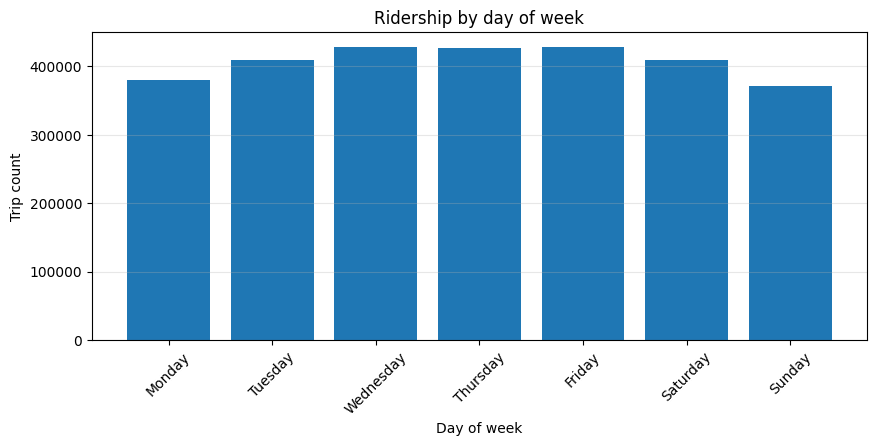

In [13]:
plt.figure(figsize=(10, 4))
plt.bar(day_counts.index, day_counts.values)
plt.xticks(rotation=45)
plt.xlabel("Day of week")
plt.ylabel("Trip count")
plt.title("Ridership by day of week")
plt.grid(axis="y", alpha=0.3)
plt.show()

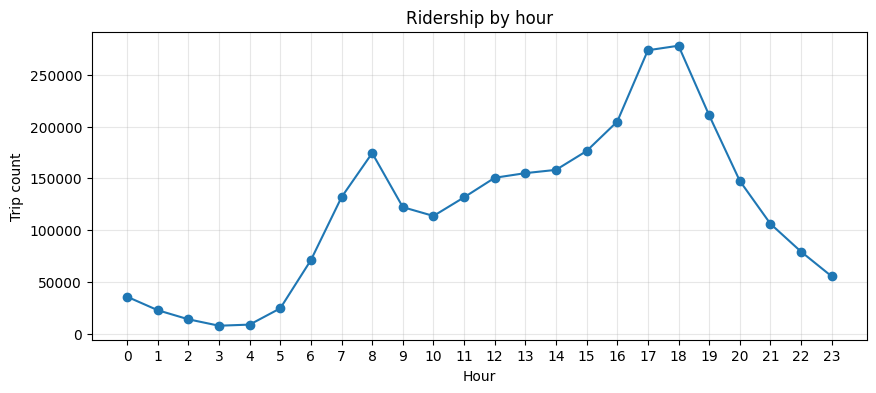

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(hour_counts.index, hour_counts.values, marker="o")
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Trip count")
plt.title("Ridership by hour")
plt.grid(alpha=0.3)
plt.show()

**Aggregate for daily and hourly analysis**

In [15]:
daily_bike = df.groupby("date", as_index=False).agg(
    daily_trip_count=("ride_id", "count"),
    avg_tripduration_min=("tripduration_min", "mean"),
    median_tripduration_min=("tripduration_min", "median"),
    casual_share=("member_casual", lambda s: (s == "casual").mean()),
    member_share=("member_casual", lambda s: (s == "member").mean()),
)

hourly_bike = df.groupby(["date", "hour"], as_index=False).agg(
    hourly_trip_count=("ride_id", "count")
)

display(daily_bike.head())
display(hourly_bike.head())

,date,daily_trip_count,avg_tripduration_min,median_tripduration_min,casual_share,member_share
0,2021-02-01,2,8.700000,8.700000,0.000000,1.000000
1,2021-02-03,38,501.289474,15.675000,0.157895,0.842105
2,2021-02-04,85,15.838235,12.183333,0.176471,0.823529
3,2021-02-05,161,15.901346,9.033333,0.180124,0.819876
4,2021-02-06,221,703.083861,10.466667,0.266968,0.733032


,date,hour,hourly_trip_count
0,2021-02-01,0.0,1
1,2021-02-01,6.0,1
2,2021-02-03,12.0,2
3,2021-02-03,13.0,2
4,2021-02-03,14.0,3


## 5. NOAA Weather Addition & Treatment

The NOAA CDO v2 docs say to use:
- base URL `https://www.ncei.noaa.gov/cdo-web/api/v2/{endpoint}`
- token in the request header

In [16]:
datasets_preview = noaa_paginated_get(
    "datasets",
    params={"limit": 25},
    token=NOAA_TOKEN,
    limit=25,
)
display(datasets_preview[["id", "name", "mindate", "maxdate", "datacoverage"]].head(15))

ghcnd_info = noaa_get("datasets/GHCND", token=NOAA_TOKEN)
ghcnd_info

,id,name,mindate,maxdate,datacoverage
0,GHCND,Daily Summaries,1763-01-01,2026-04-04,1.00
1,GSOM,Global Summary of the Month,1763-01-01,2026-03-01,1.00
2,GSOY,Global Summary of the Year,1763-01-01,2026-01-01,1.00
3,NEXRAD2,Weather Radar (Level II),1991-06-05,2026-04-05,0.95
4,NEXRAD3,Weather Radar (Level III),1994-05-20,2026-04-04,0.95
5,NORMAL_ANN,Normals Annual/Seasonal,2010-01-01,2010-01-01,1.00
6,NORMAL_DLY,Normals Daily,2010-01-01,2010-12-31,1.00
7,NORMAL_HLY,Normals Hourly,2010-01-01,2010-12-31,1.00
8,NORMAL_MLY,Normals Monthly,2010-01-01,2010-12-01,1.00
9,PRECIP_15,Precipitation 15 Minute,1970-05-12,2014-01-01,0.25


{'mindate': '1763-01-01',
 'maxdate': '2026-04-04',
 'name': 'Daily Summaries',
 'datacoverage': 1,
 'id': 'GHCND'}

**Find a nearby NOAA station from the Citi Bike spatial footprint**

In [17]:
lat_min = float(min(df["start_lat"].min(), df["end_lat"].min()))
lat_max = float(max(df["start_lat"].max(), df["end_lat"].max()))
lng_min = float(min(df["start_lng"].min(), df["end_lng"].min()))
lng_max = float(max(df["start_lng"].max(), df["end_lng"].max()))
extent = f"{lat_min:.4f},{lng_min:.4f},{lat_max:.4f},{lng_max:.4f}"

print("Estimated Citi Bike extent:")
print(extent)

station_candidates = noaa_paginated_get(
    "stations",
    params={
        "datasetid": NOAA_DATASET_ID,
        "extent": extent,
        "startdate": WEATHER_START_DATE,
        "enddate": WEATHER_END_DATE,
        "sortfield": "datacoverage",
        "sortorder": "desc",
    },
    token=NOAA_TOKEN,
    limit=1000,
)

display(
    station_candidates[["id", "name", "mindate", "maxdate", "datacoverage"]].head(20)
)

Estimated Citi Bike extent:
40.6451,-74.0933,40.8724,-73.8883


,id,name,mindate,maxdate,datacoverage
0,GHCND:USW00094728,"NY CITY CENTRAL PARK, NY US",1869-01-01,2026-04-03,1.0000
1,GHCND:USW00094741,"TETERBORO AIRPORT, NJ US",1969-08-13,2026-04-03,0.9967
2,GHCND:US1NJBG0064,"WOOD RIDGE 0.2 N, NJ US",2022-04-05,2026-04-03,0.9932
3,GHCND:USC00288884,"TETERBORO AIRPORT, NJ US",2024-01-01,2026-04-04,0.9903
4,GHCND:US1NYNY0082,"MATTHEWS PALMER PLAYGROUND NEW YORK 6.8 NNW, N...",2020-11-16,2021-10-19,0.9467
5,GHCND:US1NJHD0023,"JERSEY CITY 1.6 NNE, NJ US",2024-02-11,2026-04-02,0.9386
6,GHCND:US1NJBG0018,"PALISADES PARK 0.2 WNW, NJ US",2008-02-07,2026-04-03,0.8742
7,GHCND:US1NYKN0025,"BROOKLYN 3.1 NW, NY US",2013-11-29,2024-07-16,0.7711
8,GHCND:USC00309580,"WORLD TRADE CENTER, NY US",2022-02-01,2023-07-07,0.6954
9,GHCND:USC00305816,"WORLD TRADE CENTER, NY US",1871-01-01,2024-06-17,0.5977


In [18]:
if NOAA_STATION_ID.strip():
    SELECTED_STATION_ID = NOAA_STATION_ID
elif "station_candidates" in globals() and not station_candidates.empty:
    SELECTED_STATION_ID = station_candidates.iloc[0]["id"]
else:
    SELECTED_STATION_ID = None
    print(
        "No station selected yet. Run the station lookup cell first, or set NOAA_STATION_ID manually."
    )

print("Selected station:", SELECTED_STATION_ID)

Selected station: GHCND:USW00094728


**Pull daily weather from NOAA**

In [19]:
if not SELECTED_STATION_ID:
    print(
        "Weather pull skipped. Run the station lookup cell first or set NOAA_STATION_ID manually."
    )
else:
    weather_long, weather_daily = fetch_noaa_weather_yearly(
        token=NOAA_TOKEN,
        station_id=SELECTED_STATION_ID,
        start_date=WEATHER_START_DATE,
        end_date=WEATHER_END_DATE,
        datasetid=NOAA_DATASET_ID,
        datatypes=NOAA_DATATYPES,
    )

    print("weather_long shape:", weather_long.shape)
    print("weather_daily shape:", weather_daily.shape)
    display(weather_long.head())
    display(weather_daily.head())

weather_long shape: (9247, 5)
weather_daily shape: (1854, 7)


,date,datatype,station,attributes,value
0,2021-02-01,AWND,GHCND:USW00094728,",,W,",6.4
1,2021-02-01,PRCP,GHCND:USW00094728,",,W,2400",47.0
2,2021-02-01,SNOW,GHCND:USW00094728,",,W,",376.0
3,2021-02-01,TMAX,GHCND:USW00094728,",,W,2400",1.1
4,2021-02-01,TMIN,GHCND:USW00094728,",,W,2400",-5.5


datatype,date,AWND,PRCP,SNOW,TMAX,TMIN,TAVG_EST
0,2021-02-01,6.4,47.0,376.0,1.1,-5.5,-2.20
1,2021-02-02,3.8,3.3,10.0,0.6,-1.0,-0.20
2,2021-02-03,3.4,0.3,5.0,2.8,-1.6,0.60
3,2021-02-04,3.1,0.0,0.0,6.1,-0.5,2.80
4,2021-02-05,2.2,1.8,0.0,8.3,2.8,5.55


**Join weather to daily Citi Bike**

In [20]:
if "weather_daily" not in globals() or weather_daily is None or len(weather_daily) == 0:
    print("Join skipped. Run the weather pull cell first.")
else:
    joined_daily = daily_bike.merge(weather_daily, on="date", how="left")
    display(joined_daily.head())
    display(missing_summary(joined_daily).head(20))

,date,daily_trip_count,avg_tripduration_min,median_tripduration_min,casual_share,member_share,AWND,PRCP,SNOW,TMAX,TMIN,TAVG_EST
0,2021-02-01,2,8.700000,8.700000,0.000000,1.000000,6.4,47.0,376.0,1.1,-5.5,-2.20
1,2021-02-03,38,501.289474,15.675000,0.157895,0.842105,3.4,0.3,5.0,2.8,-1.6,0.60
2,2021-02-04,85,15.838235,12.183333,0.176471,0.823529,3.1,0.0,0.0,6.1,-0.5,2.80
3,2021-02-05,161,15.901346,9.033333,0.180124,0.819876,2.2,1.8,0.0,8.3,2.8,5.55
4,2021-02-06,221,703.083861,10.466667,0.266968,0.733032,3.1,0.0,0.0,6.7,1.1,3.90


,missing_count,missing_percent
AWND,20,1.646091
date,0,0.000000
daily_trip_count,0,0.000000
avg_tripduration_min,0,0.000000
median_tripduration_min,0,0.000000
casual_share,0,0.000000
member_share,0,0.000000
PRCP,0,0.000000
SNOW,0,0.000000
TMAX,0,0.000000


**Weather Correlations**

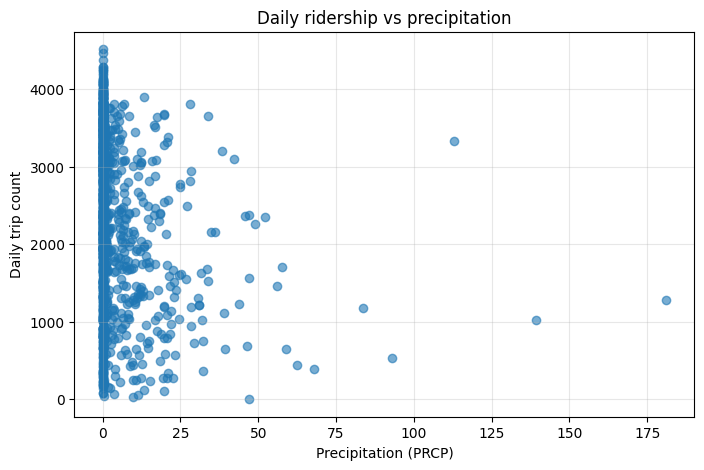

In [21]:
if "joined_daily" not in globals():
    print("Weather visualizations skipped. Run the join cell first.")
else:
    # Ridership vs precipitation
    if "PRCP" in joined_daily.columns:
        plot_df = joined_daily.dropna(subset=["daily_trip_count", "PRCP"]).copy()
        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df["PRCP"], plot_df["daily_trip_count"], alpha=0.6)
        plt.xlabel("Precipitation (PRCP)")
        plt.ylabel("Daily trip count")
        plt.title("Daily ridership vs precipitation")
        plt.grid(alpha=0.3)
        plt.show()

**Interpretation:** Most observations are concentrated near very low precipitation, and that is also where the highest ridership days appear. As precipitation increases, high-ridership days become less common, which suggests that wetter days may reduce bike usage. However, the points are still widely scattered, so precipitation alone does not explain daily ridership very well.

Note:

- Most days had little or no rain. That is why the points are heavily stacked near PRCP = 0.
- There are also a few high-precipitation outliers, which may be worth checking in case they are unusual weather days or data points.

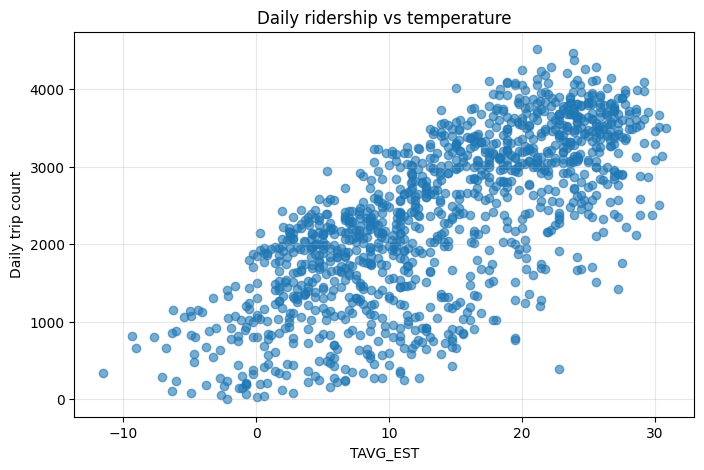

In [22]:
if "joined_daily" not in globals():
    print("Weather visualizations skipped. Run the join cell first.")
else:
    # Ridership vs estimated avg temp
    temp_col = "TAVG_EST" if "TAVG_EST" in joined_daily.columns else None
    if temp_col is not None:
        plot_df = joined_daily.dropna(subset=["daily_trip_count", temp_col]).copy()
        plt.figure(figsize=(8, 5))
        plt.scatter(plot_df[temp_col], plot_df["daily_trip_count"], alpha=0.6)
        plt.xlabel(temp_col)
        plt.ylabel("Daily trip count")
        plt.title("Daily ridership vs temperature")
        plt.grid(alpha=0.3)
        plt.show()

**Interpretation:** As estimated average temperature increases, daily trip counts also tend to increase. Colder days are associated with much lower ridership, while warmer days generally have higher ridership. This suggests that temperature is an important factor shaping bike usage.

Note: This pattern is not very surprising, since biking is an outdoor activity and more people are willing to ride when weather conditions are comfortable.

,rain_day,daily_trip_count
0,False,2560.137709
1,True,1975.180365


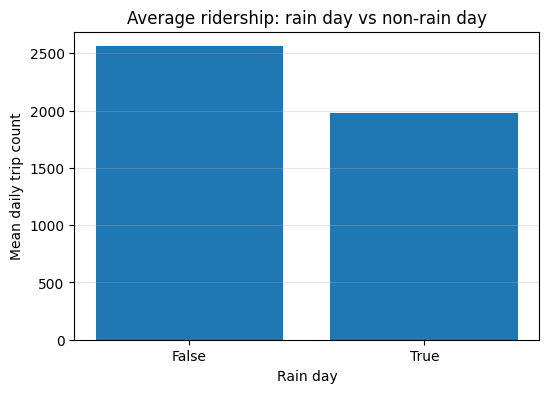

In [23]:
if "joined_daily" not in globals():
    print("Weather visualizations skipped. Run the join cell first.")
else:
    # Rain day vs non-rain day
    if "PRCP" in joined_daily.columns:
        comp = joined_daily.copy()
        comp["rain_day"] = comp["PRCP"].fillna(0) > 0
        rain_summary = comp.groupby("rain_day", as_index=False)[
            "daily_trip_count"
        ].mean()
        display(rain_summary)

        plt.figure(figsize=(6, 4))
        plt.bar(rain_summary["rain_day"].astype(str), rain_summary["daily_trip_count"])
        plt.xlabel("Rain day")
        plt.ylabel("Mean daily trip count")
        plt.title("Average ridership: rain day vs non-rain day")
        plt.grid(axis="y", alpha=0.3)
        plt.show()

**Interpretation:** On average, non-rain days have higher Citi Bike ridership than rain days. In this summary, mean daily trip count is about 2560 on non-rain days and about 1975 on rain days, which suggests that rainfall is associated with a noticeable drop in bike use.

While this comparison is descriptive rather than causal, it provides additional evidence that weather conditions, especially precipitation, are meaningfully related to daily ridership variation.

## 6. Evil analysis critique

To acheive the proposals in the evil plan, the data is
- dropping inconvenient records (rush hours, etc.)
- ignoring missingness / underrepresentation
- using a misleading metric
- training on unrepresentative time periods
- hiding uncertainty

**Evil tactic 1: drop rush-hour records**

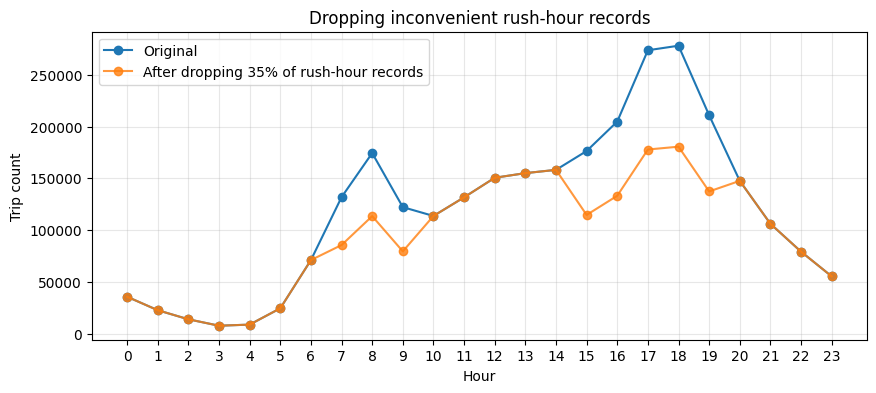

In [24]:
evil_df_drop = df.copy()
rush_idx = (
    evil_df_drop[evil_df_drop["is_rush_hour"]].sample(frac=0.35, random_state=42).index
)
evil_df_drop = evil_df_drop.drop(index=rush_idx).copy()

orig_hour = df.groupby("hour").size().reset_index(name="original_trip_count")
evil_hour = evil_df_drop.groupby("hour").size().reset_index(name="evil_trip_count")
hour_compare = orig_hour.merge(evil_hour, on="hour", how="left").fillna(0)

plt.figure(figsize=(10, 4))
plt.plot(
    hour_compare["hour"],
    hour_compare["original_trip_count"],
    marker="o",
    label="Original"
)
plt.plot(
    hour_compare["hour"],
    hour_compare["evil_trip_count"],
    marker="o",
    label="After dropping 35% of rush-hour records",
    alpha = 0.8
)
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Trip count")
plt.title("Dropping inconvenient rush-hour records")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:**

This chart compares the original hourly ridership pattern with a manipulated version that was created by removing 35% of the rush-hour records. In the original line, there are obvious commuting peaks, especially in the morning and late afternoon, which is exactly what we would normally expect in transportation data. Once those records are deleted, the manipulated line smooths out the peaks and makes demand appear more evenly distributed throughout the day.

The “evil” part is that this does not reflect a real change in behavior. It is a distortion caused by selectively removing inconvenient data points. By undercounting rush-hour trips, the analysis hides the periods when the system is actually under the greatest strain. This can make congestion seem less serious than it really is and may mislead decision-makers into believing that commuter demand is more balanced and easier to manage than it actually is.

This is unethical because it introduces bias at the data preparation stage. The removed records are not random, they are concentrated in the hours that matter most for understanding peak demand. As a result, the chart tells a false story about travel behavior. In a real-world context, this kind of manipulation could be used to justify poor planning decisions, cut service where it is actually needed, or conceal failures in transit operations.

**Evil tactic 2: clip peak hourly counts**

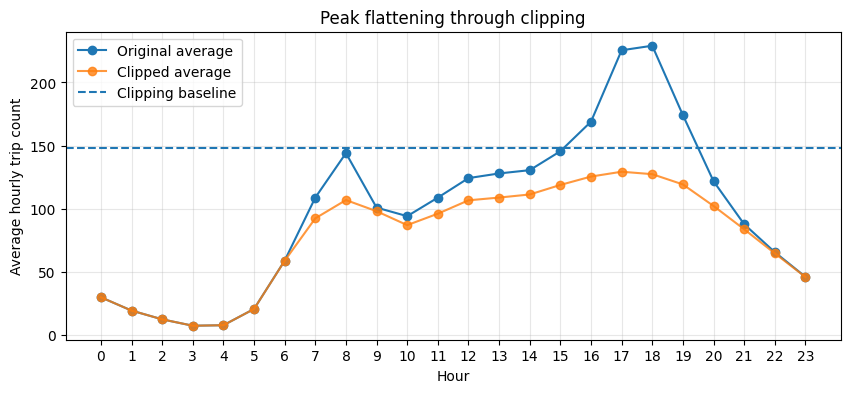

In [25]:
hourly_counts = df.groupby(["date", "hour"], as_index=False).agg(
    hourly_trip_count=("ride_id", "count")
)

clip_baseline = hourly_counts["hourly_trip_count"].quantile(0.75)
hourly_counts["evil_clipped"] = hourly_counts["hourly_trip_count"].clip(
    upper=clip_baseline
)

orig_profile = hourly_counts.groupby("hour", as_index=False)["hourly_trip_count"].mean()
clip_profile = hourly_counts.groupby("hour", as_index=False)["evil_clipped"].mean()

plt.figure(figsize=(10, 4))
plt.plot(
    orig_profile["hour"],
    orig_profile["hourly_trip_count"],
    marker="o",
    label="Original average",
)
plt.plot(
    clip_profile["hour"],
    clip_profile["evil_clipped"],
    marker="o",
    label="Clipped average",
    alpha = 0.8
)
plt.axhline(clip_baseline, linestyle="--", label="Clipping baseline")
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Average hourly trip count")
plt.title("Peak flattening through clipping")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpretation:**

The original profile shows clear morning and evening commuting peaks, with the highest spike appearing in the late afternoon. The clipped profile reduces those peaks and makes the overall ridership pattern look much flatter, especially during the busiest commuting hours. Because the orange line is pushed downward toward the clipping threshold, the chart gives the impression that demand is more moderate and consistent throughout the day than it actually is.

The “evil” part is that this is not a neutral smoothing process. The analysis is deliberately capping high hourly values so that the busiest periods no longer appear as true peaks. In other words, the manipulation hides evidence of crowding and peak demand while leaving the quieter hours mostly unchanged. This makes the system appear less stressed and can conceal the times when riders are experiencing the worst congestion.

This is unethical because it changes the underlying pattern instead of presenting it truthfully. The clipped line does not represent actual rider behavior; it represents a choice to compress inconvenient high-demand periods. In practice, this kind of manipulation could be used to justify underinvestment, dismiss the need for additional rush-hour service, or falsely suggest that demand is evenly spread across the day.

**35% Removal vs. Peak Clipping**

The 35% drop manipulation removes a portion of rush-hour records from the dataset, which directly lowers observed trip counts during peak commuting times. In contrast, peak clipping keeps the data but caps high hourly values at a chosen threshold, which flattens the busiest periods without deleting all of the underlying observations.

Both methods distort the true demand pattern, but they do so differently. The 35% drop introduces bias through selective record removal, while peak clipping introduces bias through a misleading transformation that suppresses extreme values. In both cases, the result is an artificially flatter ridership profile that hides the severity of rush-hour demand.

**Evil tactic 3: filter out weak stations**

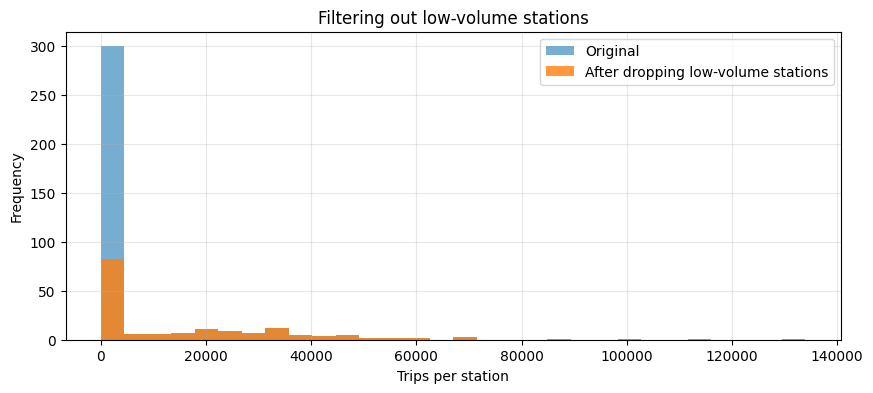

In [26]:
station_counts = (
    df.groupby("start_station_name", as_index=False)
    .agg(trip_count=("ride_id", "count"))
    .sort_values("trip_count")
)
station_cutoff = station_counts["trip_count"].quantile(0.25)
low_volume_stations = set(
    station_counts.loc[
        station_counts["trip_count"] <= station_cutoff, "start_station_name"
    ]
)

evil_station_df = df.loc[~df["start_station_name"].isin(low_volume_stations)].copy()
filtered_station_counts = evil_station_df.groupby(
    "start_station_name", as_index=False
).agg(trip_count=("ride_id", "count"))

plt.figure(figsize=(10, 4))
plt.hist(station_counts["trip_count"], bins=30, alpha=0.6, label="Original")
plt.hist(
    filtered_station_counts["trip_count"],
    bins=30,
    alpha=0.8,
    label="After dropping low-volume stations",
)
plt.xlabel("Trips per station")
plt.ylabel("Frequency")
plt.title("Filtering out low-volume stations")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Interpetation:**

This visualization compares the original station-level trip distribution with a manipulated version produced after low-volume stations were removed. In the original data, many stations show relatively low ridership, which is normal in a real transit system because not every location serves as a major hub. After the filtering step, much of the lower end of the distribution disappears, making the network seem more concentrated around stations that are already busy.

The unethical part is that this filtering treats low-ridership stations as though they are just irrelevant noise, even though they may represent neighborhoods and riders with fewer transportation options. By leaving them out, the analysis underrepresents communities that still need bike access, even when their demand is smaller in absolute terms. This can make it easier to justify moving bikes, funding, or planning attention away from those areas and toward places that are already better served. In effect, the manipulation hides inequity by presenting lower usage as a sign of unimportance rather than a possible result of limited access, uneven infrastructure, or broader structural disadvantage.

**Evil tactic 4: train on unrepresentative quiet periods**

In [27]:
metric_df = hourly_bike.copy()
metric_df["date"] = pd.to_datetime(metric_df["date"])
metric_df["day_of_week"] = metric_df["date"].dt.day_name()
metric_df["is_quiet_period"] = metric_df["day_of_week"].isin(
    ["Tuesday", "Wednesday", "Thursday"]
) & metric_df["hour"].between(1, 5)

full_train_mean = metric_df["hourly_trip_count"].mean()
quiet_train_mean = metric_df.loc[
    metric_df["is_quiet_period"], "hourly_trip_count"
].mean()

metric_df["pred_full_mean"] = full_train_mean
metric_df["pred_quiet_mean"] = quiet_train_mean
metric_df["abs_err_full"] = (
    metric_df["hourly_trip_count"] - metric_df["pred_full_mean"]
).abs()
metric_df["abs_err_quiet"] = (
    metric_df["hourly_trip_count"] - metric_df["pred_quiet_mean"]
).abs()

comparison = pd.DataFrame(
    {
        "Model": ["Train on all periods", "Train only on quiet periods"],
        "MAE_on_all_data": [
            metric_df["abs_err_full"].mean(),
            metric_df["abs_err_quiet"].mean(),
        ],
        "MAE_on_quiet_periods_only": [
            metric_df.loc[metric_df["is_quiet_period"], "abs_err_full"].mean(),
            metric_df.loc[metric_df["is_quiet_period"], "abs_err_quiet"].mean(),
        ],
    }
)
display(comparison)

,Model,MAE_on_all_data,MAE_on_quiet_periods_only
0,Train on all periods,72.458969,88.529759
1,Train only on quiet periods,90.143169,8.128408


We make the model look smart by grading it only on the easiest part of the day, then use that fake success to hide how badly it fails when the city is actually moving.

**Interpretation:** This result demonstrates how training on unrepresentative quiet periods can produce misleadingly strong performance when evaluation is restricted to the same narrow conditions. The quiet-period model appears highly accurate when tested only on low-demand hours, with an MAE of 8.13, but performs much worse on the full dataset, with an MAE of 90.14. This is the “evil” move: by choosing a calm subset of data and reporting only the favorable metric, the analysis creates the false impression that the model generalizes well. In reality, it fails to capture the more variable and operationally important busy periods, where prediction quality matters most.

**Evil tactic 5: misleading metric**

In [28]:
metric_df = hourly_bike.copy()
threshold = metric_df["hourly_trip_count"].quantile(0.75)
metric_df["high_demand"] = (metric_df["hourly_trip_count"] >= threshold).astype(int)
metric_df["evil_pred"] = 0  # always predict the majority / easier class

metric_summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "precision_high_demand",
            "recall_high_demand",
            "f1_high_demand",
        ],
        "value": [
            accuracy_score_manual(metric_df["high_demand"], metric_df["evil_pred"]),
            precision_score_manual(
                metric_df["high_demand"], metric_df["evil_pred"], positive=1
            ),
            recall_score_manual(
                metric_df["high_demand"], metric_df["evil_pred"], positive=1
            ),
            f1_score_manual(
                metric_df["high_demand"], metric_df["evil_pred"], positive=1
            ),
        ],
    }
)
display(metric_summary)

,metric,value
0,accuracy,0.749227
1,precision_high_demand,NaN
2,recall_high_demand,0.000000
3,f1_high_demand,NaN


**Potentially needs further work:** This output shows that the model appears reasonably strong if judged only by accuracy, reaching about 74.9%. However, this performance is misleading because the model simply predicts the majority class every time and never identifies any high-demand hours. As a result, recall for high demand is 0, and precision and F1 become undefined because the model never produces a positive prediction. This demonstrates how accuracy can hide severe failure in an imbalanced classification problem.

**Evil tactic 6: hide uncertainty**

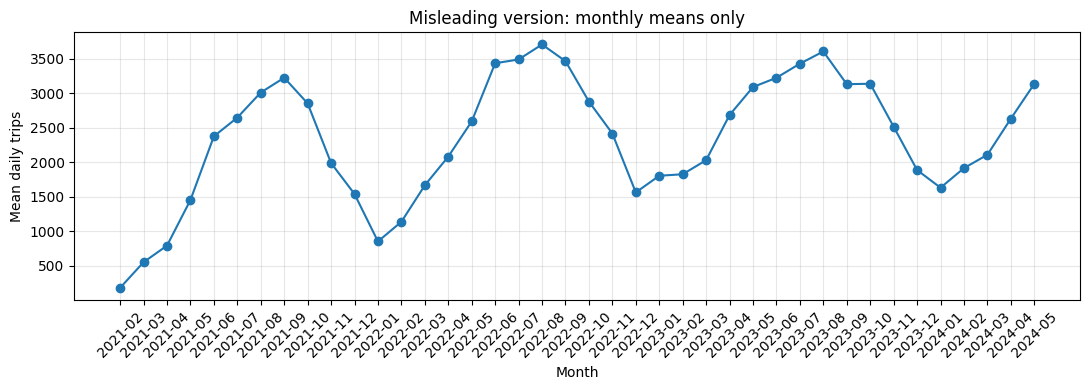

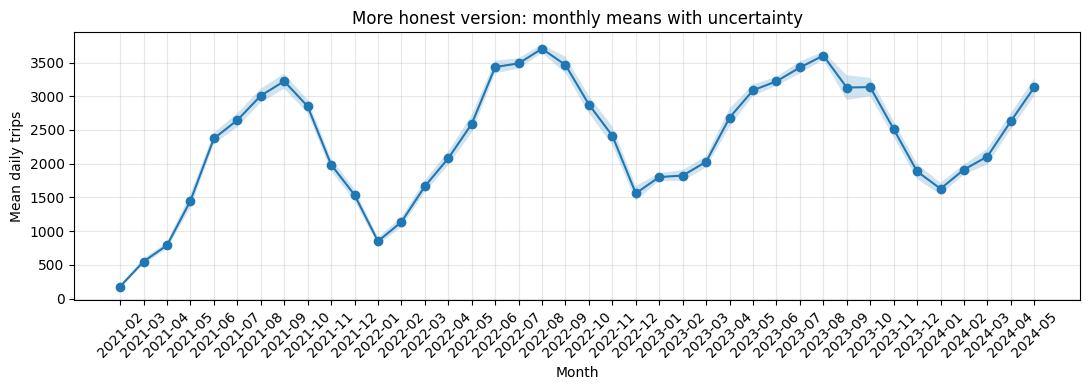

In [29]:
monthly_daily = daily_bike.copy()
monthly_daily["year_month"] = monthly_daily["date"].dt.to_period("M").astype(str)

monthly_summary = monthly_daily.groupby("year_month", as_index=False).agg(
    mean_daily_trips=("daily_trip_count", "mean"),
    std_daily_trips=("daily_trip_count", "std"),
    n_days=("daily_trip_count", "count"),
)
monthly_summary["sem"] = monthly_summary["std_daily_trips"] / np.sqrt(
    monthly_summary["n_days"].clip(lower=1)
)

plt.figure(figsize=(11, 4))
plt.plot(monthly_summary["year_month"], monthly_summary["mean_daily_trips"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Mean daily trips")
plt.title("Misleading version: monthly means only")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

x = np.arange(len(monthly_summary))
plt.figure(figsize=(11, 4))
plt.plot(x, monthly_summary["mean_daily_trips"], marker="o")
plt.fill_between(
    x,
    monthly_summary["mean_daily_trips"] - monthly_summary["sem"].fillna(0),
    monthly_summary["mean_daily_trips"] + monthly_summary["sem"].fillna(0),
    alpha=0.2,
)
plt.xticks(x, monthly_summary["year_month"], rotation=45)
plt.xlabel("Month")
plt.ylabel("Mean daily trips")
plt.title("More honest version: monthly means with uncertainty")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The trick is not to fabricate the trend, but to polish it, compressing messy daily reality into a smooth monthly story that looks more certain and trustworthy than it should.

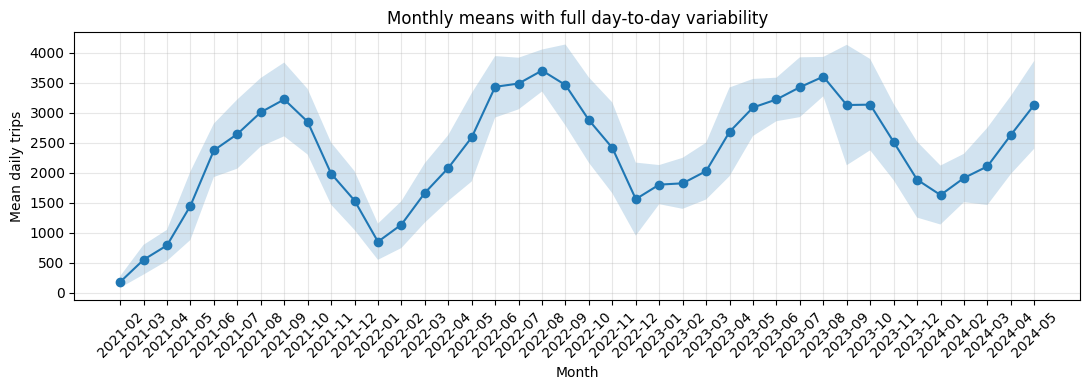

In [30]:
plt.figure(figsize=(11, 4))
plt.plot(x, monthly_summary["mean_daily_trips"], marker="o")
plt.fill_between(
    x,
    monthly_summary["mean_daily_trips"] - monthly_summary["std_daily_trips"].fillna(0),
    monthly_summary["mean_daily_trips"] + monthly_summary["std_daily_trips"].fillna(0),
    alpha=0.2,
)
plt.xticks(x, monthly_summary["year_month"], rotation=45)
plt.xlabel("Month")
plt.ylabel("Mean daily trips")
plt.title("Monthly means with full day-to-day variability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Replacing messy daily reality with a clean monthly average, making the system look calmer, more predictable, and more manageable than it actually is.

This plot shows that monthly average ridership follows a clear seasonal cycle, with higher usage in warmer months and lower usage in colder months. However, the added standard deviation band reveals that daily ridership within each month varies substantially around the monthly mean. This means the average line alone gives an incomplete picture: it captures the broad seasonal pattern but hides how much daily demand fluctuates inside each month. The unethical aspect is that an analyst could present only the smooth monthly averages to imply that ridership is stable, predictable, and easy to manage, while concealing the variability that would be important for accurate planning and honest communication.